In [1]:
#!/usr/bin/python3
import sys
import os

sys.path.append(os.path.abspath(".."))

import pickle
import Scripts.utils
from Scripts.utils import *
import numpy as np
from numpy import array
import glob
import pandas as pd
import matplotlib.pyplot as plt
import random, math
import matplotlib.ticker as ticker
import seaborn as sns
from rich.console import Console
from rich.table import Table
from matplotlib.colors import ListedColormap
from sklearn.model_selection import KFold
from tensorflow.keras.utils import plot_model
import visualkeras
from PIL import ImageFont, Image
from sklearn.metrics import r2_score

import copy
import random, math
import time
from joblib import dump
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model
from sklearn.metrics import mean_squared_error as mse
from tensorflow.keras.metrics import RootMeanSquaredError as rmse
from scipy.stats import wasserstein_distance
toGeV = 1000
# import ot
ij_cell = ['-3,3' , '-2,3' , '-1,3' , '0,3' , '1,3' , '2,3' , '3,3' , 
           '-3,2' , '-2,2' , '-1,2' , '0,2' , '1,2' , '2,2' , '3,2' , 
           '-3,1' , '-2,1' , '-1,1' , '0,1' , '1,1' , '2,1' , '3,1' , 
           '-3,0' , '-2,0' , '-1,0' , '0,0' , '1,0' , '2,0' , '3,0' , 
           '-3,-1', '-2,-1', '-1,-1', '0,-1', '1,-1', '2,-1', '3,-1', 
           '-3,-2', '-2,-2', '-1,-2', '0,-2', '1,-2', '2,-2', '3,-2', 
           '-3,-3', '-2,-3', '-1,-3', '0,-3', '1,-3', '2,-3', '3,-3' ]

2026-06-13 19:55:08.979526: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-13 19:55:09.217175: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781391309.331864  156564 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781391309.361721  156564 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-13 19:55:09.581881: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
# carregar dados
with open("time_corrupt.pkl", "rb") as f:
    time_corrupt = pickle.load(f)

with open("TimesGeVOptFilt.pkl", "rb") as f:
    TimesGeVOptFilt = pickle.load(f)

with open("y_pred_real_com_bi.pkl", "rb") as f:
    y_pred_real_com_bi = pickle.load(f)

with open("y_pred_real_sem_bi.pkl", "rb") as f:
    y_pred_real_sem_bi = pickle.load(f)

with open("predicted_energy.pkl", "rb") as f:
    predicted_energy = pickle.load(f)

with open("XTAmplitudesGeVOptFilt.pkl", "rb") as f:
    XTAmplitudesGeVOptFilt = pickle.load(f)

with open("AmplitudesGeVOptFilt.pkl", "rb") as f:
    AmplitudesGeVOptFilt = pickle.load(f)

In [3]:
tau_corrupt = np.mean(time_corrupt, axis=1)
tau_true    = np.mean(TimesGeVOptFilt, axis=1)
tau_pred    = np.mean(y_pred_real_com_bi, axis=1)

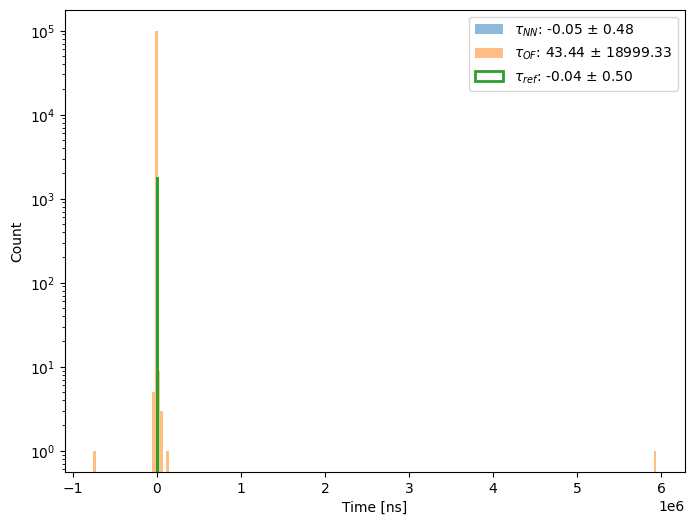

In [4]:
plt.figure(figsize=(8,6))

plt.hist(tau_pred,
         bins=200,
         histtype='stepfilled',
         alpha=0.5,
         density=False,
         label=fr'$\tau_{{NN}}$: {np.mean(tau_pred):.2f} ± {np.std(tau_pred):.2f}')

plt.hist(tau_corrupt,
         bins=200,
         histtype='stepfilled',
         alpha=0.5,
         density=False,
         label=fr'$\tau_{{OF}}$: {np.mean(tau_corrupt):.2f} ± {np.std(tau_corrupt):.2f}')

plt.hist(tau_true,
         bins=200,
         histtype='step',
         linewidth=2,
         label=fr'$\tau_{{ref}}$: {np.mean(tau_true):.2f} ± {np.std(tau_true):.2f}')

plt.yscale('log')
plt.xlabel('Time [ns]')
plt.ylabel('Count')
plt.legend()
plt.show()

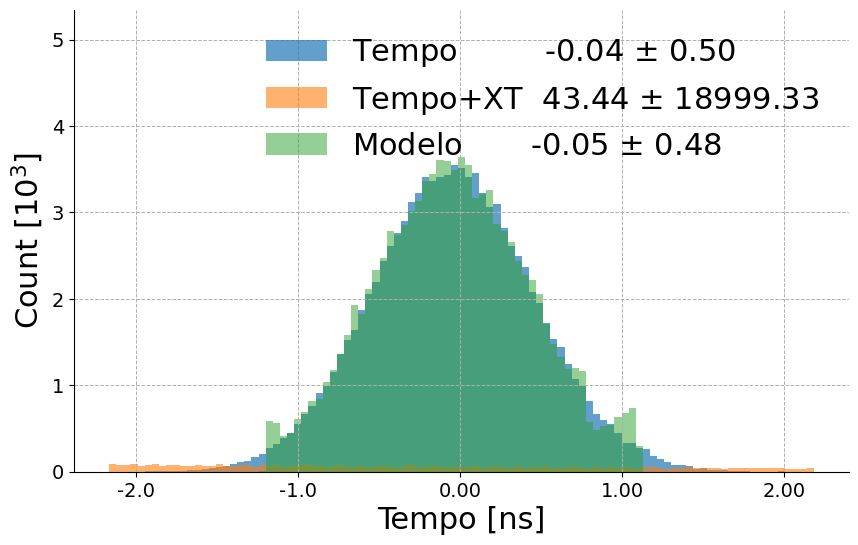

In [5]:
plotHisto(tau_true, tau_corrupt,tau_pred,  label='time', legend=['Tempo', 'Tempo+XT', 'Modelo'])

In [ ]:
predicted_energy = predicted_energy.reshape(99492, 49)
XTAmplitudesGeVOptFilt = XTAmplitudesGeVOptFilt.reshape(99492, 49)/1000
AmplitudesGeVOptFilt = AmplitudesGeVOptFilt.reshape(99492, 49)/1000

In [ ]:
from matplotlib.patches import Rectangle
distances = []

for i in range(49):
    d = wasserstein_distance(AmplitudesGeVOptFilt[:, i], predicted_energy[:, i])
    distances.append(d)

print(distances)
print("Média:", np.mean(distances))
distances = np.array(distances)
heatmap = distances.reshape(7, 7)

fig, ax = plt.subplots(figsize=(5, 4))

# Define as cores por distância ao centro
for i in range(7):
    for j in range(7):

        # Distância de Chebyshev ao centro (3,3)
        d = max(abs(i - 3), abs(j - 3))

        if d == 0:
            color = 'red'       # célula central
        elif d == 1:
            color = 'orange'    # primeira vizinhança
        elif d == 2:
            color = 'yellow'    # segunda vizinhança
        else:
            color = 'lightgreen'  # terceira vizinhança

        ax.add_patch(
            Rectangle(
                (j - 0.5, i - 0.5),
                1, 1,
                facecolor=color,
                edgecolor='black',
                alpha=0.4
            )
        )

        ax.text(
            j, i,
            f"{heatmap[i,j]:.3f}",
            ha='center',
            va='center',
            fontsize=9
        )

# Configuração dos eixos
ax.set_xlim(-0.5, 6.5)
ax.set_ylim(6.5, -0.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')

plt.title("Distância de Wasserstein por célula")
plt.tight_layout()
plt.show()

In [ ]:
distances = []

for i in range(49):
    d = wasserstein_distance(AmplitudesGeVOptFilt[:, i], XTAmplitudesGeVOptFilt[:, i])
    distances.append(d)

print(distances)
print("Média:", np.mean(distances))

distances = np.array(distances)
heatmap = distances.reshape(7, 7)

fig, ax = plt.subplots(figsize=(5, 4))

# Define as cores por distância ao centro
for i in range(7):
    for j in range(7):

        # Distância de Chebyshev ao centro (3,3)
        d = max(abs(i - 3), abs(j - 3))

        if d == 0:
            color = 'red'       # célula central
        elif d == 1:
            color = 'orange'    # primeira vizinhança
        elif d == 2:
            color = 'yellow'    # segunda vizinhança
        else:
            color = 'lightgreen'  # terceira vizinhança

        ax.add_patch(
            Rectangle(
                (j - 0.5, i - 0.5),
                1, 1,
                facecolor=color,
                edgecolor='black',
                alpha=0.4
            )
        )

        ax.text(
            j, i,
            f"{heatmap[i,j]:.3f}",
            ha='center',
            va='center',
            fontsize=9
        )

# Configuração dos eixos
ax.set_xlim(-0.5, 6.5)
ax.set_ylim(6.5, -0.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')

plt.title("Distância de Wasserstein por célula")
plt.tight_layout()
plt.show()

In [ ]:
distances = []

for i in range(49):
    d = wasserstein_distance(predicted_energy[:, i], XTAmplitudesGeVOptFilt[:, i])
    distances.append(d)

print(distances)
print("Média:", np.mean(distances))

distances = np.array(distances)
heatmap = distances.reshape(7, 7)

fig, ax = plt.subplots(figsize=(5, 4))

# Define as cores por distância ao centro
for i in range(7):
    for j in range(7):

        # Distância de Chebyshev ao centro (3,3)
        d = max(abs(i - 3), abs(j - 3))

        if d == 0:
            color = 'red'       # célula central
        elif d == 1:
            color = 'orange'    # primeira vizinhança
        elif d == 2:
            color = 'yellow'    # segunda vizinhança
        else:
            color = 'lightgreen'  # terceira vizinhança

        ax.add_patch(
            Rectangle(
                (j - 0.5, i - 0.5),
                1, 1,
                facecolor=color,
                edgecolor='black',
                alpha=0.4
            )
        )

        ax.text(
            j, i,
            f"{heatmap[i,j]:.3f}",
            ha='center',
            va='center',
            fontsize=9
        )

# Configuração dos eixos
ax.set_xlim(-0.5, 6.5)
ax.set_ylim(6.5, -0.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')

plt.title("Distância de Wasserstein por célula")
plt.tight_layout()
plt.show()

In [ ]:
## plotting for hotest cell according to cell addressing
cell = 0

unit = 'ns'
if unit.lower() == 'gev': toGeV = 1
else: toGeV = 1

#plotHisto(map_EtruthAmp_cells_cropped[:, cell]/toGeV, xDataAmp10GeV_error[:, cell]/toGeV, label='energy', legend=['E', 'E+XT'], unit=unit, text=f'Cell {ij_cell[cell]}')
plotHisto(AmplitudesGeVOptFilt[:, cell]/1000, XTAmplitudesGeVOptFilt[:, cell]/1000, predicted_energy[:, cell], label='energy', legend=['Energy', 'Energy+XT', 'Predicted'], unit=unit, text=f'Célula {ij_cell[cell]}')

In [ ]:
import os
import matplotlib.pyplot as plt

## cria a pasta
save_dir = "histogramas_cells_time_dataset"
os.makedirs(save_dir, exist_ok=True)

unit = 'ns'

if unit.lower() == 'ns':
    toGeV = 1
else:
    toGeV = 1

## loop das 49 células
for cell in range(49):
    ## chama sua função
    plotHisto(
        TimesGeVOptFilt[:, cell],
        time_corrupt[:, cell],
        label='time',
        legend=['Tempo', 'Tempo+XT'],
        unit=unit,
        text=f'Célula {ij_cell[cell]}',
        pathOut = "histogramas_cells_time_dataset",
        save = True,
        fileName = "histo_time_" + str(cell)

    )
print(f"Histogramas salvos em: {save_dir}")

In [ ]:
import os
import matplotlib.pyplot as plt

## cria a pasta
save_dir = "histogramas_cells_energy"
os.makedirs(save_dir, exist_ok=True)

unit = 'GeV'

if unit.lower() == 'gev':
    toGeV = 1
else:
    toGeV = 1

## loop das 49 células
for cell in range(49):
    ## chama sua função
    plotHisto(
        TimesGeVOptFilt[:, cell],
        time_corrupt[:, cell],
        y_pred_real_com_bi[:, cell],
        label='time',
        legend=['Tempo', 'Tempo+XT', 'Predição_B'],
        unit=unit,
        text=f'Célula {ij_cell[cell]}',
        pathOut = "histogramas_cells_time_B",
        save = True,
        fileName = "histo_time_B_" + str(cell)

    )
print(f"Histogramas salvos em: {save_dir}")

In [ ]:
rmse_pred = []
rmse_noise = []

for i in range(AmplitudesGeVOptFilt.shape[1]):

    # RMSE da predição
    rmse_pred_i = np.sqrt(
        mean_squared_error(
            AmplitudesGeVOptFilt[:, i] / 1000,
            predicted_energy[:, i]
        )
    )

    # RMSE do dado com ruído
    rmse_noise_i = np.sqrt(
        mean_squared_error(
            AmplitudesGeVOptFilt[:, i] / 1000,
            XTAmplitudesGeVOptFilt[:, i]/1000
        )
    )

    rmse_pred.append(rmse_pred_i)
    rmse_noise.append(rmse_noise_i)

rmse_pred = np.array(rmse_pred)
rmse_noise = np.array(rmse_noise)

In [ ]:
percent_improvement = (
    (rmse_noise - rmse_pred) / rmse_noise
) * 100

In [ ]:
percent_improvement

In [ ]:
improvement_map = percent_improvement.reshape(7, 7)

In [ ]:
plt.imshow(improvement_map, cmap='RdYlGn')
plt.colorbar(label='Melhora percentual do RMSE (%)')
plt.title('Redução percentual do RMSE')
plt.show()